In [ ]:
import os, random
import numpy as np
import torch
from local_negotiator_v2 import load_negotiator_dataset, prepare_dataset
from superglue_negotiator_new import (
    SuperGlueSwarmMatcher,
    train_superglue_matcher,
    evaluate_superglue_matcher,
)

SEED = 42
DATASET = './dataset/negotiator_dataset_v1.pt'
INIT_CKPT = './model/superglue_negotiator_best_new_v3.pt'
OUT = './model/superglue_negotiator_best_new_v4.pt'
EPOCHS = 80
LR = 1e-4
MAX_TRAIN = 5000
MAX_VAL = 500
MAX_TEST = 500

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | Torch: {torch.__version__}')


Device: cuda | Torch: 2.10.0+cu128


In [2]:
model = SuperGlueSwarmMatcher().to(DEVICE)
if os.path.isfile(INIT_CKPT):
    ckpt = torch.load(INIT_CKPT, map_location=DEVICE, weights_only=False)
    state = ckpt.get('model_state_dict', ckpt)
    current = model.state_dict()
    compatible = {
        k: v for k, v in state.items()
        if k in current and current[k].shape == v.shape
    }
    model.load_state_dict(compatible, strict=False)
    print(f'Initialized from {INIT_CKPT}: {len(compatible)}/{len(current)} tensors loaded')
else:
    print(f'No init checkpoint found at {INIT_CKPT}; training from scratch')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

raw = load_negotiator_dataset(DATASET)
train_data, val_data, test_data = prepare_dataset(
    raw,
    model.formation_embedding.weight.detach().cpu(),
    seed=SEED,
    force_gt_visibility=False,
)
train_data = train_data[:MAX_TRAIN]
val_data = val_data[:MAX_VAL]
test_data = test_data[:MAX_TEST]
print(f'Train={len(train_data)} Val={len(val_data)} Test={len(test_data)}')


Initialized from ./model/superglue_negotiator_best_new_v3.pt: 329/329 tensors loaded
Parameters: 624,546
Train=5000 Val=50 Test=50


In [7]:
print('=== SuperGlue matcher baseline before training ===')
baseline = evaluate_superglue_matcher(model, test_data[:200], DEVICE)
for k, v in baseline.items(): print(f'  {k}: {v:.4f}')


=== SuperGlue matcher baseline before training ===
  bijection_rate: 0.8000
  conflict_rate: 0.0147
  unassigned_rate: 0.0000
  cost_ratio_vs_hungarian: 0.9990
  slot_match_rate: 0.8842
  consensus_rounds: 0.0000
  mean_eps: 0.8709


In [8]:
print('=== Training SuperGlueSwarmMatcher ===')
history = train_superglue_matcher(
    model,
    train_data,
    val_data,
    DEVICE,
    epochs=EPOCHS,
    lr=LR,
    force_gt_train=True,
    eval_subset=200,
    ckpt_path=OUT,
)


KeyboardInterrupt: 

In [9]:
print('=== Final SuperGlue matcher evaluation ===')
final = evaluate_superglue_matcher(model, test_data, DEVICE)
for k, v in final.items(): print(f'  {k}: {v:.4f}')

torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'epochs': EPOCHS,
        'lr': LR,
        'inference': 'SuperGlue-style masked cross-attention matcher; greedy hardening only',
    },
    'history': history,
    'metrics': {'test': final},
}, OUT)
print(f'Saved -> {OUT}')


=== Final SuperGlue matcher evaluation ===
  bijection_rate: 0.8000
  conflict_rate: 0.0147
  unassigned_rate: 0.0000
  cost_ratio_vs_hungarian: 0.9990
  slot_match_rate: 0.8842
  consensus_rounds: 0.0000
  mean_eps: 0.8709
Saved -> ./model/superglue_negotiator_best_new_v4.pt


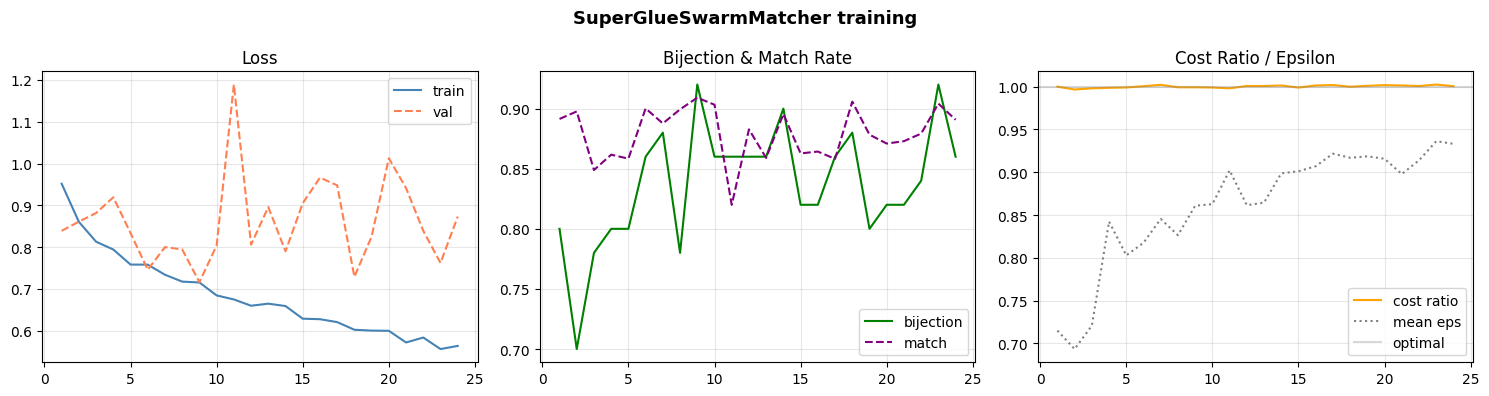

Saved superglue_negotiator_training_curves.png


In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('SuperGlueSwarmMatcher training', fontsize=13, fontweight='bold')
ep = range(1, len(history['train_loss']) + 1)
axes[0].plot(ep, history['train_loss'], label='train', color='steelblue')
axes[0].plot(ep, history['val_loss'], label='val', color='coral', linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history['val_bijection_rate'], label='bijection', color='green')
axes[1].plot(ep, history['val_slot_match_rate'], label='match', color='purple', linestyle='--')
axes[1].set_title('Bijection & Match Rate'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep, history['val_cost_ratio_vs_hungarian'], label='cost ratio', color='orange')
axes[2].plot(ep, history['val_mean_eps'], label='mean eps', color='gray', linestyle=':')
axes[2].axhline(1.0, color='gray', linestyle='-', alpha=0.3, label='optimal')
axes[2].set_title('Cost Ratio / Epsilon'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('superglue_negotiator_training_curves.png', dpi=120)
plt.show()
print('Saved superglue_negotiator_training_curves.png')
